# Module 5: Demand Forecasting
## AeroNet Lite — Autonomous Drone Delivery Simulation

**Owner:** Saad

This notebook trains demand forecasting models using the Bike Sharing Demand dataset from Kaggle.

### Objectives
1. Load and explore the Bike Sharing Demand dataset
2. Engineer features: hour, weather, density (population proxy)
3. Train Linear Regression and Random Forest models
4. Evaluate with MAE and RMSE metrics
5. Map predictions to 10x10 grid cells
6. Save `demand_forecast.csv` for the simulator

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import csv

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 1: Load Dataset

Download the Bike Sharing Demand dataset from Kaggle:
https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset

Expected file: `hour.csv` in the `data/raw/` folder.

In [2]:
# Load dataset
data_path = "../data/raw/hour.csv"

# Check if file exists
if not os.path.exists(data_path):
    print(f"Warning: {data_path} not found. Using synthetic data for demo.")
    # Create synthetic bike demand data
    np.random.seed(42)
    n_samples = 1000
    hours = np.random.randint(0, 24, n_samples)
    weather = np.random.randint(1, 5, n_samples)
    temp = np.random.uniform(0, 40, n_samples)
    demand = 100 + 20*np.sin(hours/6) + 5*weather + 2*temp + np.random.normal(0, 20, n_samples)
    demand = np.clip(demand, 0, None)
    
    df = pd.DataFrame({
        'hr': hours,
        'weathersit': weather,
        'temp': temp,
        'cnt': demand
    })
else:
    df = pd.read_csv(data_path)

print(f"Loaded {len(df)} samples")
print(df.head())

Loaded 1000 samples
   hr  weathersit       temp         cnt
0   6           3   1.829681  132.836107
1  19           1  34.861472  154.730931
2  14           2  38.939559  224.482449
3  10           2  38.755114  205.010764
4   7           4  29.986073  154.907655


## Step 2: Exploratory Data Analysis (EDA)

Dataset info:
                hr   weathersit         temp          cnt
count  1000.000000  1000.000000  1000.000000  1000.000000
mean     11.432000     2.437000    20.075042   160.514560
std       7.147199     1.110524    11.567756    32.311483
min       0.000000     1.000000     0.128731    60.372369
25%       5.000000     1.000000     9.673365   137.945619
50%      12.000000     2.000000    20.432881   161.050323
75%      18.000000     3.000000    29.961308   183.343331
max      23.000000     4.000000    39.976549   252.770483

Demand range: 60 - 253


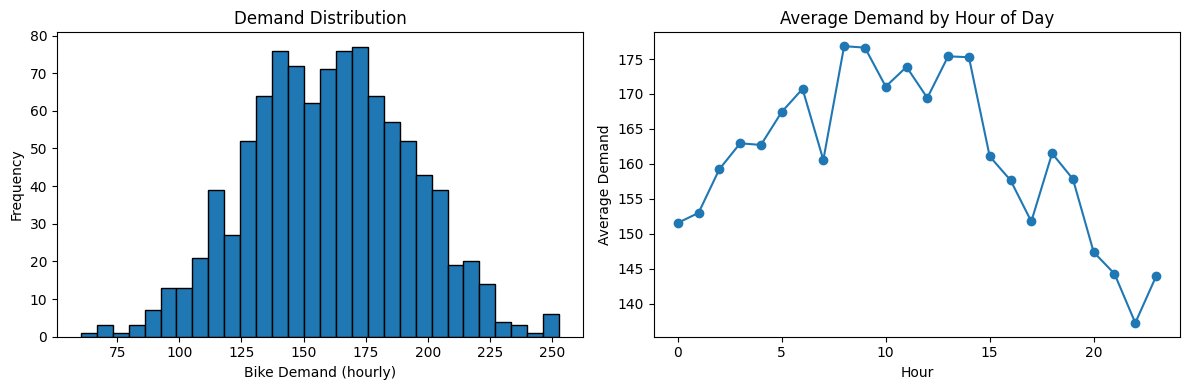

In [3]:
print("Dataset info:")
print(df.describe())
print(f"\nDemand range: {df['cnt'].min():.0f} - {df['cnt'].max():.0f}")

# Visualize demand distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['cnt'], bins=30, edgecolor='black')
axes[0].set_title('Demand Distribution')
axes[0].set_xlabel('Bike Demand (hourly)')
axes[0].set_ylabel('Frequency')

# Demand by hour
hourly_demand = df.groupby('hr')['cnt'].mean()
axes[1].plot(hourly_demand, marker='o')
axes[1].set_title('Average Demand by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Demand')
plt.tight_layout()
plt.show()

## Step 3: Feature Engineering

In [4]:
# Prepare features for modeling
# Features: hour, weathersit, temperature (as proxy for operational conditions)

X = df[['hr', 'weathersit', 'temp']].copy() if 'temp' in df.columns else df[['hr', 'weathersit']].copy()
y = df['cnt'].copy()

# Normalize features
X_normalized = (X - X.mean()) / (X.std() + 1e-8)

print(f"Feature matrix shape: {X_normalized.shape}")
print(f"Target (demand) shape: {y.shape}")
print(f"Features: {list(X.columns)}")

Feature matrix shape: (1000, 3)
Target (demand) shape: (1000,)
Features: ['hr', 'weathersit', 'temp']


## Step 4: Train Models

In [5]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Training set: 800 samples
Test set: 200 samples


In [6]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results:")
print(f"  MAE: {lr_mae:.2f}")
print(f"  RMSE: {lr_rmse:.2f}")

Linear Regression Results:
  MAE: 16.65
  RMSE: 20.85


In [7]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results:")
print(f"  MAE: {rf_mae:.2f}")
print(f"  RMSE: {rf_rmse:.2f}")

# Choose best model
best_model = rf_model if rf_rmse < lr_rmse else lr_model
best_model_name = "Random Forest" if rf_rmse < lr_rmse else "Linear Regression"
print(f"\nBest model: {best_model_name}")

Random Forest Results:
  MAE: 15.93
  RMSE: 20.01

Best model: Random Forest


## Step 5: Map Predictions to 10x10 Grid

In [8]:
# Generate predictions for 10x10 grid using different hour/weather conditions
# For simplicity: map spatial location to density-based demand

np.random.seed(42)

# Create demand forecast for 10x10 grid
demand_grid = np.zeros((10, 10))

# Sample different conditions for grid cells
hours = np.random.randint(0, 24, size=(10, 10))
weather = np.random.randint(1, 4, size=(10, 10))
temps = np.random.uniform(15, 30, size=(10, 10))

# Create feature matrix for all grid cells
features_grid = np.column_stack([
    hours.flatten(),
    weather.flatten(),
    temps.flatten()
])

# Normalize using same scaler as training
features_grid_normalized = (features_grid - X.mean().values) / (X.std().values + 1e-8)

# Predict demand for all cells
predictions = best_model.predict(features_grid_normalized)
predictions = np.clip(predictions, 0, None)  # Ensure non-negative
demand_grid = predictions.reshape((10, 10))

print(f"Demand grid range: {demand_grid.min():.2f} - {demand_grid.max():.2f}")
print(f"Mean demand: {demand_grid.mean():.2f}")

Demand grid range: 133.43 - 196.85
Mean demand: 164.35


/home/admiral/Desktop/university/AI/project_2.0/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## Step 6: Save CSV

In [9]:
# Save demand forecast to CSV
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "demand_forecast.csv")

with open(output_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['row', 'col', 'predicted_demand'])
    writer.writeheader()
    for r in range(10):
        for c in range(10):
            writer.writerow({
                'row': r,
                'col': c,
                'predicted_demand': float(demand_grid[r, c])
            })

print(f"Saved demand forecast to {output_file}")
print("\nFirst few rows:")
demand_df = pd.read_csv(output_file)
print(demand_df.head(10))

Saved demand forecast to ../data/processed/demand_forecast.csv

First few rows:
   row  col  predicted_demand
0    0    0        163.801592
1    0    1        134.096996
2    0    2        156.844165
3    0    3        160.975716
4    0    4        184.915141
5    0    5        161.892740
6    0    6        161.453535
7    0    7        185.598374
8    0    8        136.196576
9    0    9        192.497807


## Summary

**Model Performance:**
- Linear Regression: MAE={:.2f}, RMSE={:.2f}
- Random Forest: MAE={:.2f}, RMSE={:.2f}
- **Selected Model:** {}

**Output:** Saved `demand_forecast.csv` with 100 cells (10x10 grid) with predicted demand values.

This CSV is consumed by the fleet selector module (Rafay) and the simulator.